In [2]:
import cv2
import numpy as np

# Load image
image_path = "images/4X9A0960.JPG"
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Image not found at path: {image_path}")

# Get original dimensions
height, width = img.shape[:2]

# Define ROI as percentage of width and height
x_start_pct = 0.12   # 12% from left
x_end_pct = 0.88     # 88% from left
y_start_pct = 0.04   # 4% from top
y_end_pct = 0.98     # 98% from top

# Convert percentage to actual pixel values
x_start = int(width * x_start_pct)
x_end = int(width * x_end_pct)
y_start = int(height * y_start_pct)
y_end = int(height * y_end_pct)

# Crop image
cropped = img[y_start:y_end, x_start:x_end]

# Convert to grayscale without resizing
final_gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)

# Save result
output_path = "final.jpg"
cv2.imwrite(output_path, final_gray)
print(f"Processed image saved to: {output_path}")


Processed image saved to: final.jpg


In [4]:
import cv2
import numpy as np
import os

# Input and output folders
input_folder = "image"
output_folder = "processed_images"

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Define ROI as percentage of width and height
x_start_pct = 0.12   # 12% from left
x_end_pct = 0.88     # 88% from left
y_start_pct = 0.04   # 4% from top
y_end_pct = 0.98     # 98% from top

# Supported image extensions
supported_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

# Process each image in the input folder
for filename in os.listdir(input_folder):
    if filename.lower().endswith(supported_extensions):
        image_path = os.path.join(input_folder, filename)
        img = cv2.imread(image_path)

        if img is None:
            print(f"Failed to load image: {image_path}")
            continue

        # Get original dimensions
        height, width = img.shape[:2]

        # Convert percentage to actual pixel values
        x_start = int(width * x_start_pct)
        x_end = int(width * x_end_pct)
        y_start = int(height * y_start_pct)
        y_end = int(height * y_end_pct)

        # Crop and convert to grayscale
        cropped = img[y_start:y_end, x_start:x_end]
        final_gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)

        # Save result
        output_path = os.path.join(output_folder, f"processed_{filename}")
        cv2.imwrite(output_path, final_gray)
        print(f"Processed and saved: {output_path}")


Processed and saved: processed_images\processed_4X9A0960.JPG
Processed and saved: processed_images\processed_4X9A1019.JPG
Processed and saved: processed_images\processed_c1.jpg
Processed and saved: processed_images\processed_c2.jpg
Processed and saved: processed_images\processed_ev3.JPG
Processed and saved: processed_images\processed_final_processed_ev3_image1.jpg
Processed and saved: processed_images\processed_gray_image.jpg


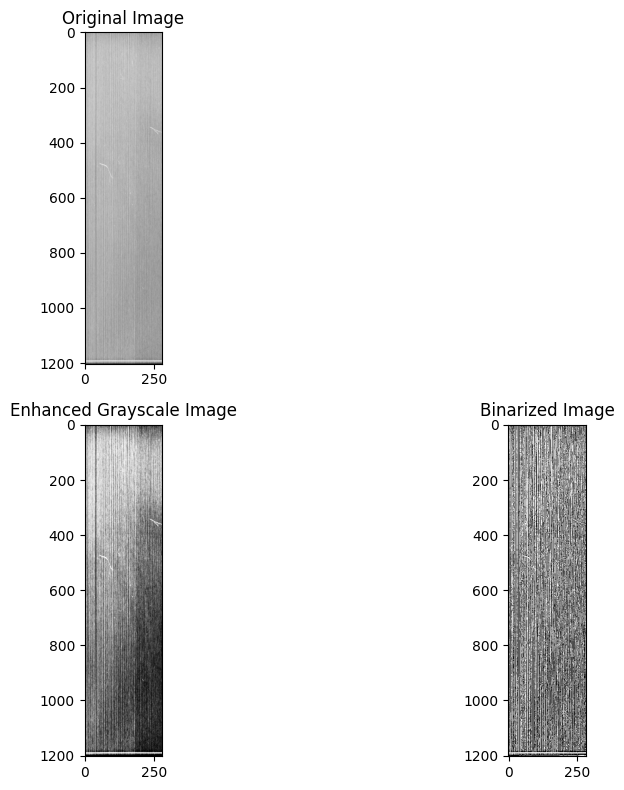

True

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = "processed_images/processed_c2.jpg"
image = cv2.imread(image_path)

# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Enhance the contrast using histogram equalization
enhanced_image = cv2.equalizeHist(gray_image)

# Apply adaptive thresholding for binarization
binarized_image = cv2.adaptiveThreshold(enhanced_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

# Visualize the results
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))


plt.subplot(2, 2, 3)
plt.title("Enhanced Grayscale Image")
plt.imshow(enhanced_image, cmap='gray')

plt.subplot(2, 2, 4)
plt.title("Binarized Image")
plt.imshow(binarized_image, cmap='gray')

plt.tight_layout()
plt.show()

# Save preprocessed images if needed
cv2.imwrite("binarized_image.jpg", binarized_image)
cv2.imwrite("grey_image.jpg", enhanced_image)


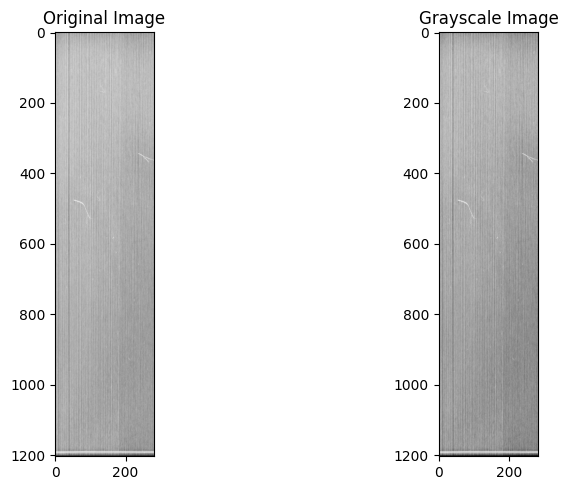

True

In [10]:
import cv2
from matplotlib import pyplot as plt

# Load the image
image_path = "processed_images/processed_c2.jpg"
image = cv2.imread(image_path)

# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the original and grayscale images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title("Grayscale Image")
plt.imshow(gray_image, cmap='gray')

plt.tight_layout()
plt.show()

# Save the grayscale image
cv2.imwrite("gray_image.jpg", gray_image)
